<h2>TIME DOMAIN ANALYSIS</h2>
<hr>
<small>Note: Section header formatted using HTML in a Markdown cell.</small>

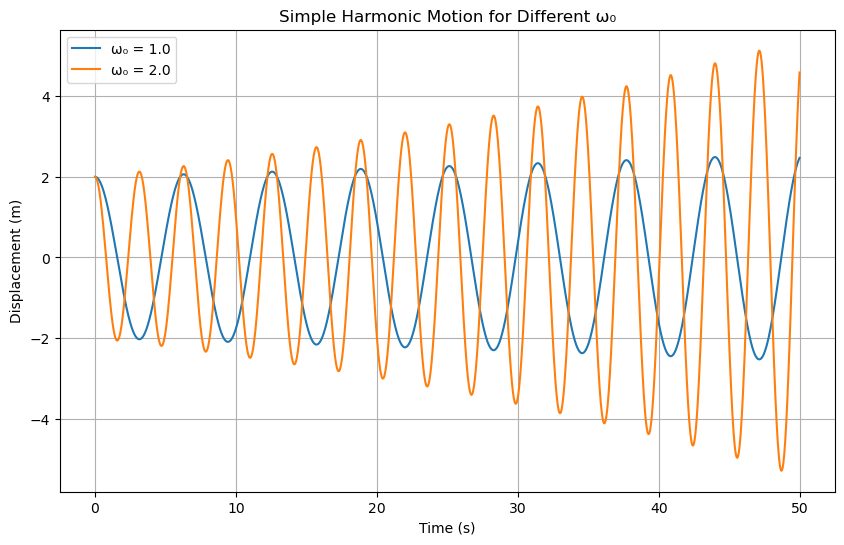

In [19]:
import numpy as np
import matplotlib.pyplot as plt

"""
Simple Harmonic Oscillator (No Damping)
=======================================

Equation:
    d²x/dt² + ω₀² x = 0

This represents an ideal system with no energy loss.
"""

# Parameters 
omega_values = [1.0, 2.0]   # two different ω₀ values

# Initial conditions
x0 = 2.0
v0 = 0.0

# Time setup
dt = 0.01
t = np.arange(0,50,dt)


# Simulation function

def simulate(omega0):
    x = np.zeros(len(t))
    v = np.zeros(len(t))

    x[0] = x0
    v[0] = v0

    for i in range(len(t) - 1):
        a = - (omega0**2) * x[i]
        v[i+1] = v[i] + a * dt
        x[i+1] = x[i] + v[i] * dt
    return x


# Plot
plt.figure(figsize=(10,6))
for omega0 in omega_values:
    x = simulate(omega0)
    plt.plot(t, x, label=f"ω₀ = {omega0}")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Simple Harmonic Motion for Different ω₀")
plt.legend()
plt.grid()
plt.show()

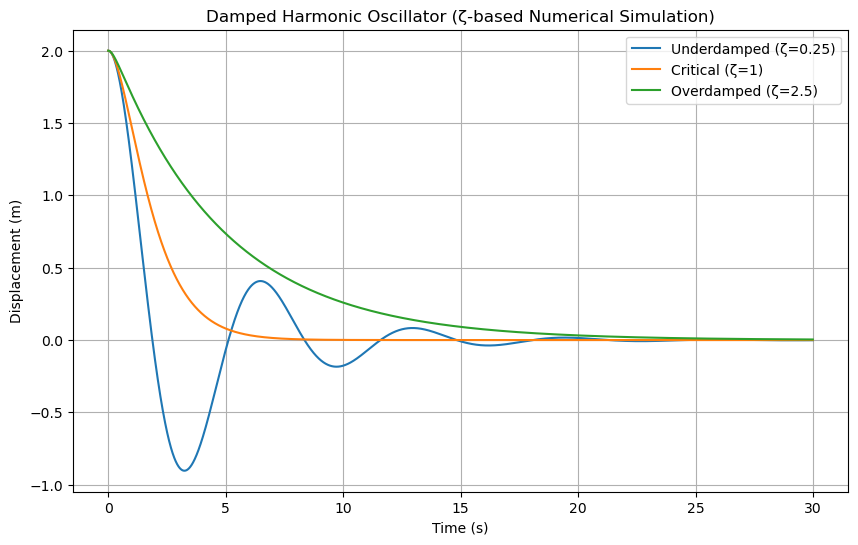

'\nNote: Codes for certain symbols \nζ = print("ζ")\nω = print("ω")  \nΩ = print("Ω")  \n\n'

In [17]:
import numpy as np
import matplotlib.pyplot as plt

"""
Damping Regimes (Underdamped, Critical, Overdamped)
===================================================

Governing Equation:

    m * d²x/dt² + c * dx/dt + k * x = 0
    
Equation of a damped harmonic oscillator (in zeta terms):

    d²x/dt² + 2ζω₀ dx/dt + ω₀² x = 0

Where:

    x(t): Displacement (m)
    ω₀ = sqrt(k/m) : Natural frequency of the system (rad/s)
    ζ (zeta) = c / (2 * sqrt(m * k)) : Damping ratio (dimensionless)

        ζ < 1  → Underdamped (oscillatory decay)
        ζ = 1  → Critically damped (fastest non-oscillatory return)
        ζ > 1  → Overdamped (slow, non-oscillatory decay)
"""

# Parameters
m = 1.0        # mass (kg)
k = 1.0        # spring constant (N/m)

omega0 = np.sqrt(k/m)   # natural frequency

# Damping ratio
zeta_values = [0.25, 1.0, 2.5]

# Initial conditions
x0 = 2.0
v0 = 0.0

# Time setup
dt = 0.01
t = np.arange(0, 30, dt)


# Simulation (Euler method)

def simulate(zeta):
    x = np.zeros(len(t))
    v = np.zeros(len(t))

    x[0] = x0
    v[0] = v0

    for i in range(len(t) - 1):
        # acceleration from equation:
        # x'' + 2*zeta*omega0*x' + omega0^2*x = 0
        a = -2*zeta*omega0*v[i] - (omega0**2)*x[i]
        v[i+1] = v[i] + a*dt
        x[i+1] = x[i] + v[i]*dt
    return x


# Plot
plt.figure(figsize=(10,6))
for zeta in zeta_values:
    x = simulate(zeta)

    if zeta < 1:
        label = f"Underdamped (ζ={zeta})"
    elif zeta == 1:
        label = "Critical (ζ=1)"
    else:
        label = f"Overdamped (ζ={zeta})"

    plt.plot(t, x, label=label)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Damped Harmonic Oscillator (ζ-based Numerical Simulation)")
plt.legend()
plt.grid()
plt.show()

"""
Note: Codes for certain symbols 
ζ = print("\u03B6")
ω = print("\u03C9")  
Ω = print("\u03A9")  

"""

<h2>FREQUENCY DOMAIN ANALYSIS: TRANSFER FUNCTION</h2>
<hr>

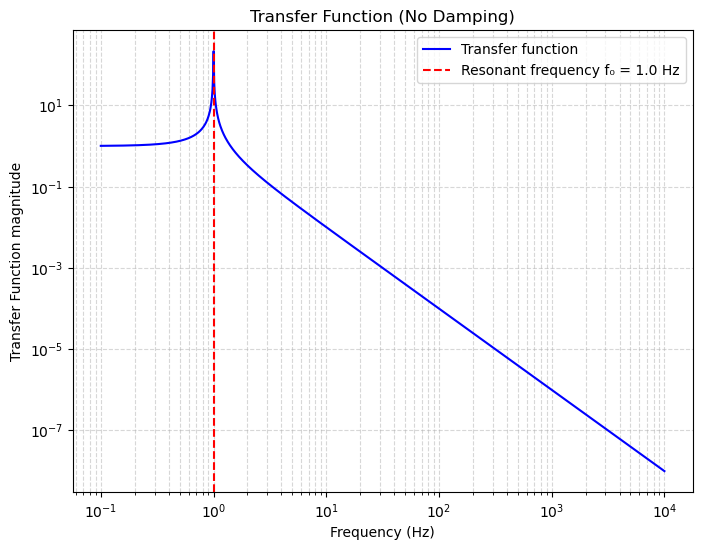

In [21]:
import numpy as np
import matplotlib.pyplot as plt

"""
Transfer Function of a Vibrational Isolator (No Damping)
========================================================
   
    |x/x_g| = f0^2 / |f0^2 - f^2|

Where:

    x   : Displacement of the mass
    x_g : Displacement of the ground (input)

    f   : Driving frequency (Hz)
    f₀  : Natural (resonant) frequency (Hz)


Shows how displacement response varies with frequency.
"""

# Parameters
f0 = 1.0   # resonant frequency (Hz)

# Frequency range (log scale)
f = np.logspace(-1, 4, 1000)  # 0.1 Hz to 10^4 Hz


# Transfer function
H = (f0**2) / np.abs(f0**2 - f**2)

# To Avoid division blow-up at resonance
H[f == f0] = np.nan


# Plot
plt.figure(figsize=(8,6))
plt.loglog(f, H, color='blue', label="Transfer function")
plt.axvline(f0, color='red', linestyle='--', label=f"Resonant frequency f₀ = {f0} Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Transfer Function magnitude")
plt.title("Transfer Function (No Damping)")
plt.legend()
plt.grid(which="both", linestyle='--',  alpha=0.5)
plt.show()

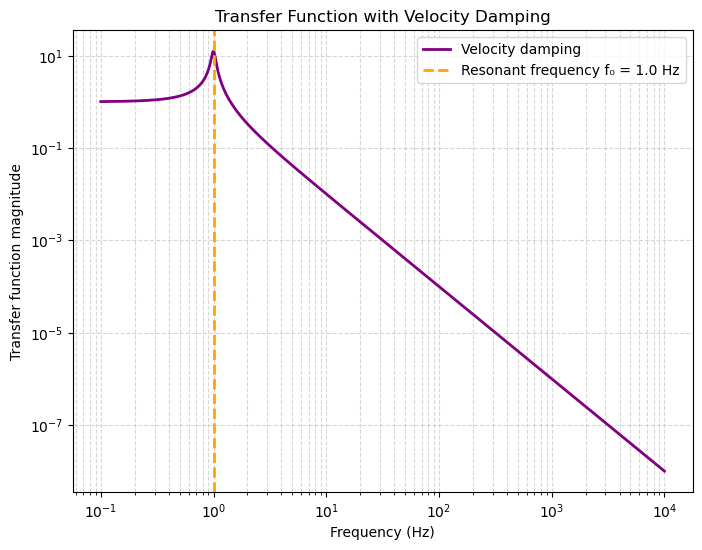

In [23]:
import numpy as np
import matplotlib.pyplot as plt

"""
Transfer Function with Velocity Damping
=======================================

    x / x_g = f₀² / (f₀² - f² + i * (f b / 2πm))

Where:

    m  : Mass (kg)
    b  : Damping coefficient (velocity damping)
"""

# Parameters
f0 = 1.0        # resonant frequency (Hz)
m = 1.0         # mass (kg)
b = 0.5         # damping constant

# Frequency range
f = np.logspace(-1, 4, 1000)


# Transfer function
numerator = f0**2
denominator = np.sqrt((f0**2 - f**2)**2 + (f * b / (2*np.pi*m))**2)

H = numerator / denominator


# Plot
plt.figure(figsize=(8,6))
plt.loglog(f, H, color='purple', linewidth=2, label="Velocity damping")
plt.axvline(f0, color='orange', linestyle='--', linewidth=2, label=f"Resonant frequency f₀ = {f0} Hz")       
plt.xlabel("Frequency (Hz)")
plt.ylabel("Transfer function magnitude")
plt.title("Transfer Function with Velocity Damping")
plt.legend()
plt.grid(which="both", linestyle='--', alpha=0.5)
plt.show()

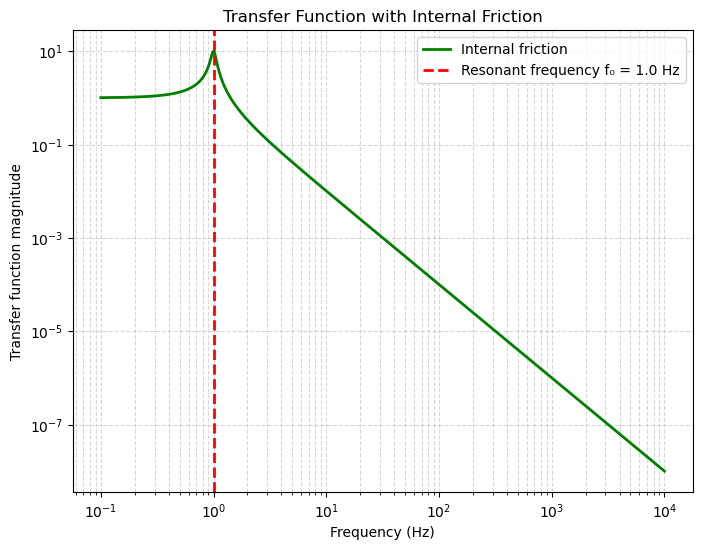

In [27]:
import numpy as np
import matplotlib.pyplot as plt

"""
Transfer Function with Internal Friction Damping
================================================

    x/x_g = f₀² (1 + iφ) / (f₀² - f² + i f₀² φ)

Where:

    φ : internal friction (loss factor)
"""

# Parameters
f0 = 1.0     # resonant frequency (Hz)
phi = 0.1    # loss factor

# Frequency range
f = np.logspace(-1, 4, 1000)

# Transfer function
numerator = f0**2 * np.sqrt(1 + phi**2)
denominator = np.sqrt((f0**2 - f**2)**2 + (f0**2 * phi)**2)

H = numerator / denominator

# Plot
plt.figure(figsize=(8,6))
plt.loglog(f, H, color='green', linewidth=2, label="Internal friction")
plt.axvline(f0, color='red', linestyle='--', linewidth=2, label=f"Resonant frequency f₀ = {f0} Hz")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Transfer function magnitude")
plt.title("Transfer Function with Internal Friction")
plt.legend()
plt.grid(which="both", linestyle='--', alpha=0.5)
plt.show()